# DRIVE Distance Map from GT

This notebook generates distance maps from DRIVE vessel masks in both `train/masks` and `test/masks`.
It writes outputs as `.npy` to `masks_dist/` and `masks_dist_inverted/` inside each split.

In [1]:
from pathlib import Path

import numpy as np
from PIL import Image
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt

import autorootcwd

In [2]:
data_root = Path("data/DRIVE")
splits = ["train", "test"]
save_preview_png = True

for split in splits:
    split_dir = data_root / split
    mask_dir = split_dir / "masks"
    out_signed_dir = split_dir / "masks_dist"
    out_inverted_dir = split_dir / "masks_dist_inverted"

    out_signed_dir.mkdir(parents=True, exist_ok=True)
    out_inverted_dir.mkdir(parents=True, exist_ok=True)

    print(f"[{split}] mask_dir={mask_dir}")
    print(f"[{split}] out_signed_dir={out_signed_dir}")
    print(f"[{split}] out_inverted_dir={out_inverted_dir}")

[train] mask_dir=data/DRIVE/train/masks
[train] out_signed_dir=data/DRIVE/train/masks_dist
[train] out_inverted_dir=data/DRIVE/train/masks_dist_inverted
[test] mask_dir=data/DRIVE/test/masks
[test] out_signed_dir=data/DRIVE/test/masks_dist
[test] out_inverted_dir=data/DRIVE/test/masks_dist_inverted


In [3]:
def normalize_01(x: np.ndarray) -> np.ndarray:
    x_min = float(x.min())
    x_max = float(x.max())
    if x_max == x_min:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - x_min) / (x_max - x_min)).astype(np.float32)


def build_distance_maps_for_split(split: str, preview_png: bool = True) -> None:
    split_dir = data_root / split
    mask_dir = split_dir / "masks"
    out_signed_dir = split_dir / "masks_dist"
    out_inverted_dir = split_dir / "masks_dist_inverted"

    mask_files = sorted(mask_dir.glob("*.gif"))
    print(f"[{split}] found {len(mask_files)} mask files")

    raw_sum_signed = 0.0
    raw_count_signed = 0
    raw_sum_inverted = 0.0
    raw_count_inverted = 0

    for mask_path in mask_files:
        mask = np.array(Image.open(mask_path).convert("L"))
        binary = (mask > 0).astype(np.uint8)

        dist_raw = distance_transform_edt(binary)
        dist_signed = normalize_01(dist_raw)

        dist_inv_raw = dist_raw.copy()
        if np.any(dist_inv_raw > 0):
            max_val = dist_inv_raw.max()
            dist_inv_raw[dist_inv_raw > 0] = max_val - dist_inv_raw[dist_inv_raw > 0]
        dist_inverted = normalize_01(dist_inv_raw)

        raw_sum_signed += float(dist_raw.sum())
        raw_count_signed += dist_raw.size
        raw_sum_inverted += float(dist_inv_raw.sum())
        raw_count_inverted += dist_inv_raw.size

        signed_npy = out_signed_dir / f"{mask_path.stem}_dist.npy"
        inverted_npy = out_inverted_dir / f"{mask_path.stem}_dist_inverted.npy"

        np.save(signed_npy, dist_signed)
        np.save(inverted_npy, dist_inverted)

        if preview_png:
            signed_png = out_signed_dir / f"{mask_path.stem}_dist.png"
            inverted_png = out_inverted_dir / f"{mask_path.stem}_dist_inverted.png"
            Image.fromarray((dist_signed * 255.0).astype(np.uint8)).save(signed_png)
            Image.fromarray((dist_inverted * 255.0).astype(np.uint8)).save(inverted_png)

    mean_signed = raw_sum_signed / raw_count_signed if raw_count_signed else float("nan")
    mean_inverted = raw_sum_inverted / raw_count_inverted if raw_count_inverted else float("nan")

    print(f"[{split}] pre-normalization mean (signed): {mean_signed:.6f}")
    print(f"[{split}] pre-normalization mean (inverted): {mean_inverted:.6f}")

In [4]:
for split in splits:
    build_distance_maps_for_split(split=split, preview_png=save_preview_png)

print("Done. DRIVE distance maps are generated.")

[train] found 20 mask files
[train] pre-normalization mean (signed): 0.137337
[train] pre-normalization mean (inverted): 0.428748
[test] found 20 mask files
[test] pre-normalization mean (signed): 0.139347
[test] pre-normalization mean (inverted): 0.410888
Done. DRIVE distance maps are generated.


In [5]:
def show_examples(split: str, n: int = 3) -> None:
    split_dir = data_root / split
    mask_dir = split_dir / "masks"
    out_signed_dir = split_dir / "masks_dist"
    out_inverted_dir = split_dir / "masks_dist_inverted"

    mask_files = sorted(mask_dir.glob("*.gif"))[:n]
    print(f"[{split}] visualizing {len(mask_files)} samples")

    for mask_path in mask_files:
        mask = np.array(Image.open(mask_path).convert("L"))
        signed = np.load(out_signed_dir / f"{mask_path.stem}_dist.npy", allow_pickle=True)
        inverted = np.load(out_inverted_dir / f"{mask_path.stem}_dist_inverted.npy", allow_pickle=True)

        plt.figure(figsize=(15, 4))

        plt.subplot(1, 3, 1)
        plt.title(f"{split} - {mask_path.name} (mask)")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("signed distance")
        plt.imshow(signed, cmap="magma")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("inverted distance")
        plt.imshow(inverted, cmap="magma")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

[train] visualizing 3 samples


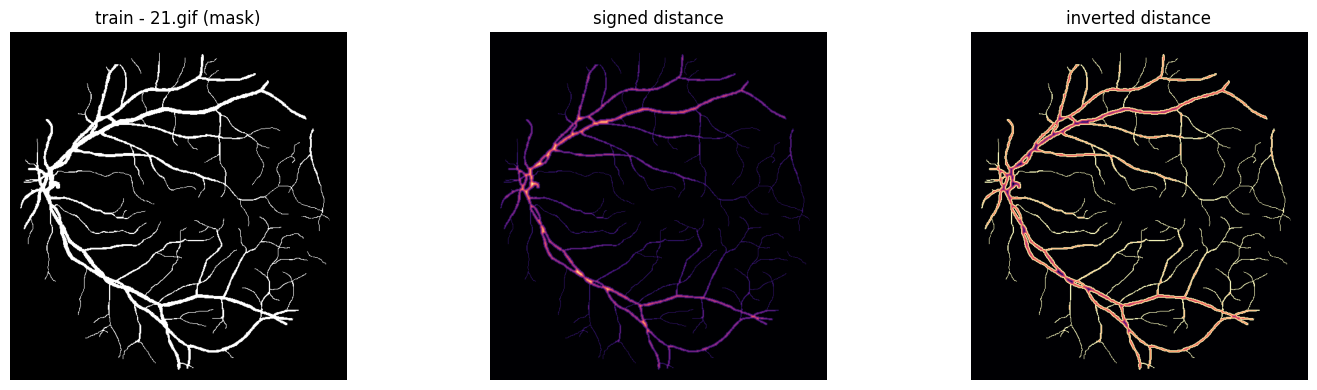

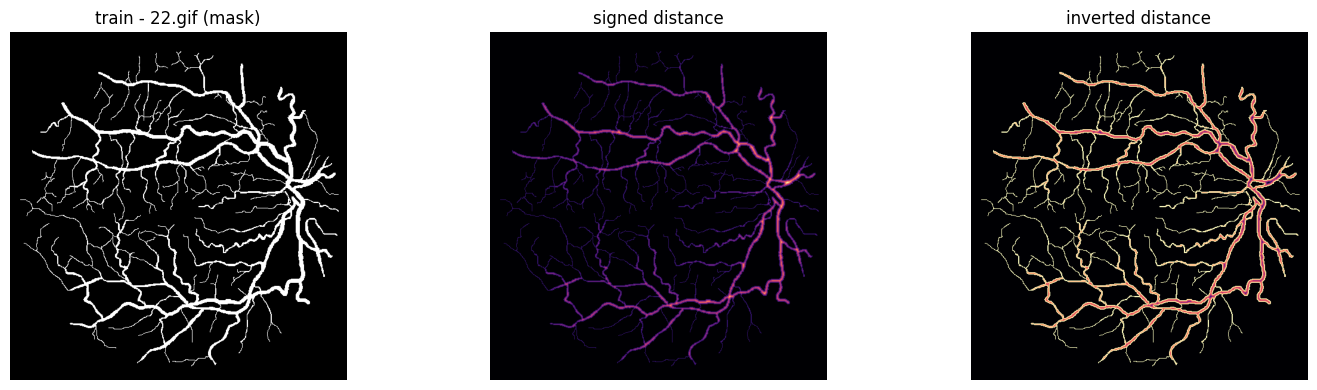

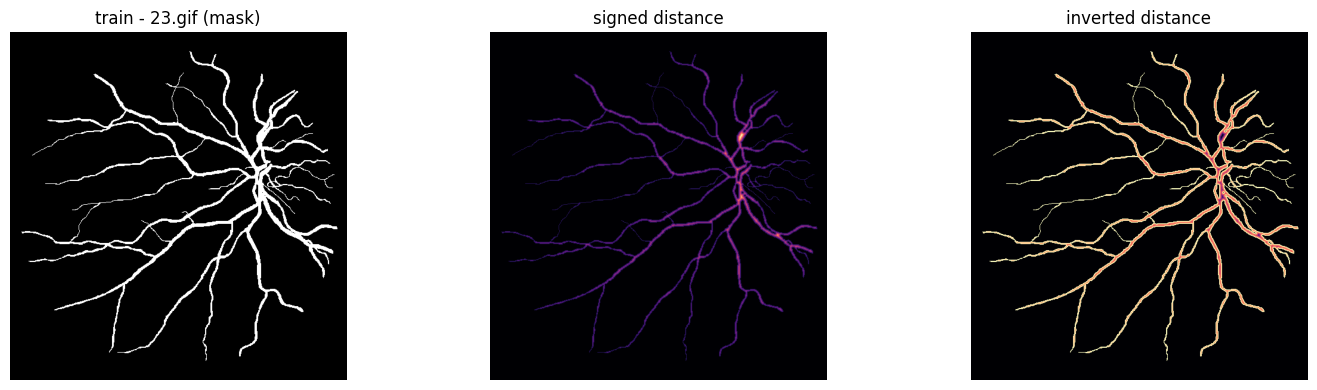

[test] visualizing 3 samples


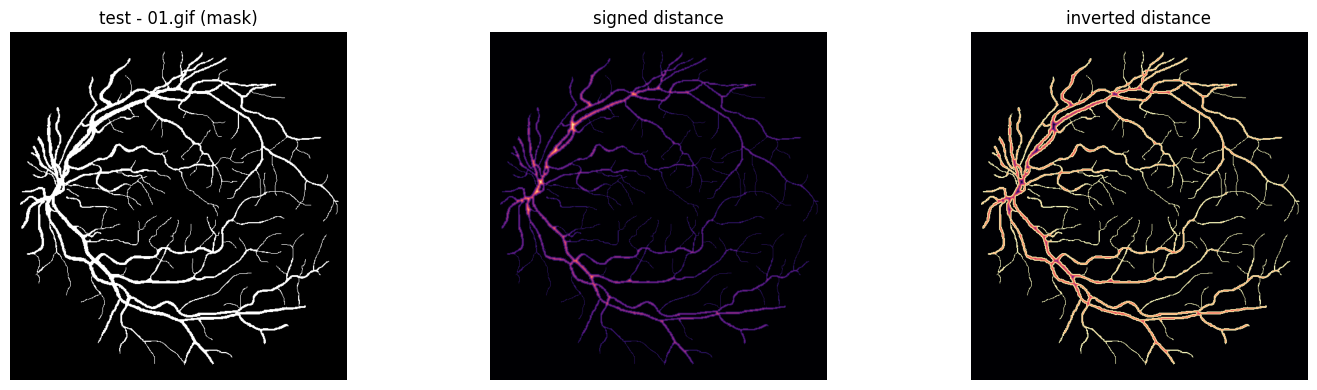

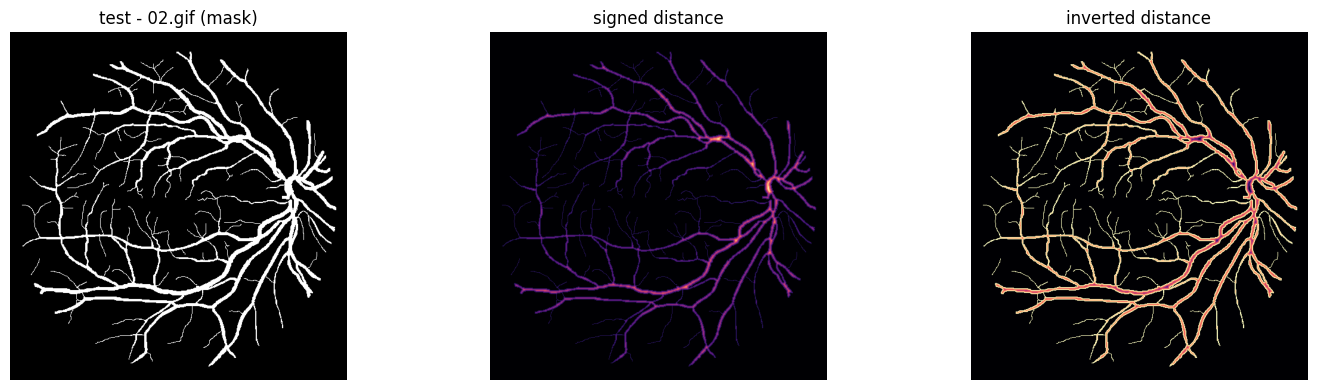

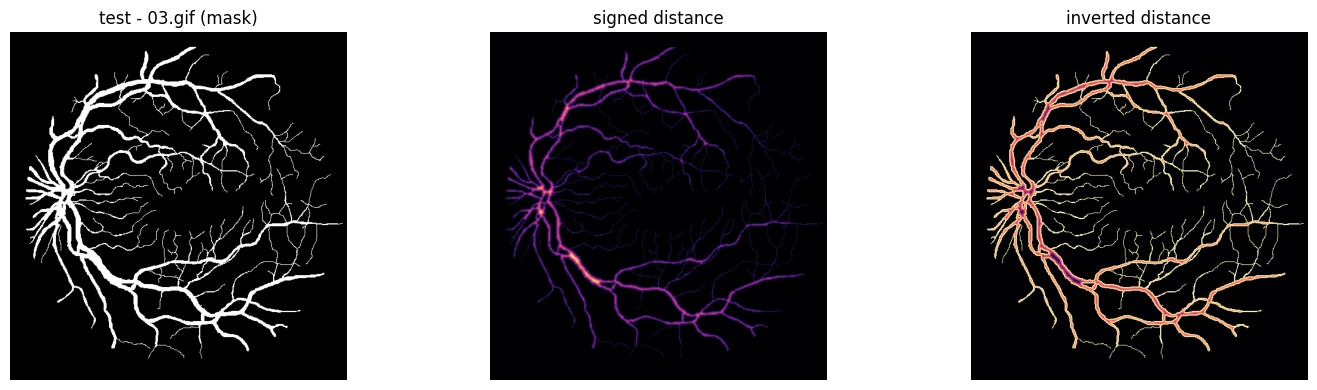

In [6]:
show_examples("train", n=3)
show_examples("test", n=3)

## MyDataset_DRIVE 실제 데이터 검증 (`binary`, `dist`, `dist_inverted`)

아래 셀은 실제 `data/DRIVE/{train,test}`를 직접 사용해 `MyDataset_DRIVE` 로딩을 검증합니다.

- `binary`: `masks/*.gif`
- `dist`: `masks_dist/*_dist.npy`
- `dist_inverted`: `masks_dist_inverted/*_dist_inverted.npy`

추가로 Linux 환경에서 자주 발생하는 경로 대소문자 문제(`data/drive` vs `data/DRIVE`)를 함께 점검합니다.

In [ ]:
from pathlib import Path
from types import SimpleNamespace

import torch

from data_loader.GetDataset_CHASE import MyDataset_DRIVE


def inspect_drive_roots() -> None:
    root_ok = Path("data/DRIVE")
    root_bad = Path("data/drive")

    print(f"exists(data/DRIVE)={root_ok.exists()}")

    for split in ["train", "test"]:
        img_cnt = len(list((root_ok / split / "images").glob("*.tif")))
        mask_cnt = len(list((root_ok / split / "masks").glob("*.gif")))
        dist_cnt = len(list((root_ok / split / "masks_dist").glob("*_dist.npy")))
        inv_cnt = len(list((root_ok / split / "masks_dist_inverted").glob("*_dist_inverted.npy")))
        print(f"[{split}] images={img_cnt}, masks={mask_cnt}, dist={dist_cnt}, dist_inverted={inv_cnt}")


def _inspect_one_sample(ds: MyDataset_DRIVE, label_mode: str) -> None:
    img, mask, name = ds[0]
    img = img.detach().cpu()
    mask = mask.detach().cpu()

    print(f"sample name: {name}")
    print(f"img shape={tuple(img.shape)}, dtype={img.dtype}, range=({img.min().item():.4f}, {img.max().item():.4f})")
    print(f"mask shape={tuple(mask.shape)}, dtype={mask.dtype}, range=({mask.min().item():.4f}, {mask.max().item():.4f})")

    if label_mode == "binary":
        unique_vals = torch.unique(mask)
        print("binary unique values:", unique_vals.tolist()[:8])


def validate_mydataset_drive(label_mode: str) -> None:
    assert label_mode in {"binary", "dist", "dist_inverted"}

    args = SimpleNamespace(dataset="drive")

    for split in ["train", "test"]:
        split_root = Path("data/DRIVE") / split
        mode = "train" if split == "train" else "test"

        ds = MyDataset_DRIVE(args, train_root=str(split_root), mode=mode, label_mode=label_mode)

        print("=" * 80)
        print(f"label_mode={label_mode}, split={split}, len={len(ds)}")
        assert len(ds) > 0, f"Dataset is empty for split={split}, label_mode={label_mode}"

        _inspect_one_sample(ds, label_mode)

        if label_mode in {"dist", "dist_inverted"}:
            _, m, _ = ds[min(1, len(ds) - 1)]
            m = m.detach().cpu()
            assert m.min().item() >= -1e-6 and m.max().item() <= 1.0 + 1e-6, (
                f"Distance mask out of [0,1] range for split={split}, mode={label_mode}: "
                f"min={m.min().item()}, max={m.max().item()}"
            )

        print(f"PASS: split={split}, label_mode={label_mode}")

In [8]:
inspect_drive_roots()

for mode in ["binary", "dist", "dist_inverted"]:
    validate_mydataset_drive(mode)

exists(data/DRIVE)=True
exists(data/drive)=False
[train] images=20, masks=20, dist=20, dist_inverted=20
[test] images=20, masks=20, dist=20, dist_inverted=20
label_mode=binary, split=train, len=20
sample name: 21
img shape=(3, 960, 960), dtype=torch.float32, range=(-1.6000, 1.6000)
mask shape=(1, 960, 960), dtype=torch.float32, range=(0.0000, 1.0000)
binary unique values: [0.0, 1.0]
PASS: split=train, label_mode=binary
label_mode=binary, split=test, len=20
sample name: 09
img shape=(3, 960, 960), dtype=torch.float32, range=(-1.6000, 1.6000)
mask shape=(1, 960, 960), dtype=torch.float32, range=(0.0000, 1.0000)
binary unique values: [0.0, 1.0]
PASS: split=test, label_mode=binary
label_mode=dist, split=train, len=20
sample name: 21
img shape=(3, 960, 960), dtype=torch.float32, range=(-1.6000, 1.6000)
mask shape=(1, 960, 960), dtype=torch.float32, range=(0.0000, 0.9871)
PASS: split=train, label_mode=dist
label_mode=dist, split=test, len=20
sample name: 09
img shape=(3, 960, 960), dtype=tor